In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel(
    "../../data/clustering/ml_dataset.xlsx"
)

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (437, 5)
Columns: ['road_id', 'hour', 'day', 'delay', 'congestion']


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

print("\nLast 5 Records:")
display(df.tail())

Dataset Shape: (437, 5)

Column Names:
['road_id', 'hour', 'day', 'delay', 'congestion']

First 5 Records:


,road_id,hour,day,delay,congestion
0,R1,14,Monday,0.07,FREE
1,R2,14,Monday,-0.65,FREE
2,R3,14,Monday,-0.25,FREE
3,R4,14,Monday,-0.25,FREE
4,R1,16,Monday,-0.23,FREE



Last 5 Records:


,road_id,hour,day,delay,congestion
432,R4,22,Wednesday,-0.12,FREE
433,R1,17,Sunday,1.27,LIGHT
434,R2,17,Sunday,0.10,FREE
435,R3,17,Sunday,1.25,LIGHT
436,R4,17,Sunday,0.22,FREE


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   road_id     437 non-null    object 
 1   hour        437 non-null    int64  
 2   day         437 non-null    object 
 3   delay       437 non-null    float64
 4   congestion  437 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 17.2+ KB


In [6]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,hour,delay
count,437.000000,437.000000
mean,16.027460,0.695309
std,4.581492,1.355432
min,0.000000,-3.250000
25%,12.000000,-0.080000
50%,18.000000,0.400000
75%,19.000000,1.550000
max,23.000000,5.070000


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
road_id       0
hour          0
day           0
delay         0
congestion    0
dtype: int64


In [8]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 24


In [9]:
print("Unique Values in Each Column:")
for column in df.columns:
    print(column, ":", df[column].nunique())

Unique Values in Each Column:
road_id : 4
hour : 17
day : 7
delay : 222
congestion : 4


In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['hour', 'delay']

Categorical Columns:
['road_id', 'day', 'congestion']


In [11]:
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows before removal: 24
Duplicate rows after removal: 0
New dataset shape: (413, 5)


In [12]:
print("Road IDs:")
print(df["road_id"].unique())

print("\nDays:")
print(df["day"].unique())

print("\nCongestion Levels:")
print(df["congestion"].unique())

Road IDs:
['R1' 'R2' 'R3' 'R4']

Days:
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']

Congestion Levels:
['FREE' 'LIGHT' 'MODERATE' 'HEAVY']


In [13]:
print("Hour range:", df["hour"].min(), "to", df["hour"].max())

print("Delay range:", df["delay"].min(), "to", df["delay"].max())

Hour range: 0 to 23
Delay range: -3.25 to 5.07


In [14]:
Q1 = df["delay"].quantile(0.25)
Q3 = df["delay"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[
    (df["delay"] < lower_limit) |
    (df["delay"] > upper_limit)
]

print("Number of outliers:", len(outliers))
display(outliers)

Q1: -0.13
Q3: 1.5
IQR: 1.63
Lower Limit: -2.5749999999999997
Upper Limit: 3.945
Number of outliers: 10


,road_id,hour,day,delay,congestion
220,R1,19,Friday,5.02,HEAVY
224,R1,19,Friday,4.45,HEAVY
228,R1,19,Friday,4.38,HEAVY
353,R1,19,Monday,5.07,HEAVY
357,R1,19,Monday,4.30,HEAVY
361,R1,19,Monday,4.18,HEAVY
373,R1,0,Tuesday,-3.07,FREE
376,R4,0,Tuesday,-3.25,FREE
393,R1,20,Tuesday,4.42,HEAVY
397,R1,20,Tuesday,4.73,HEAVY


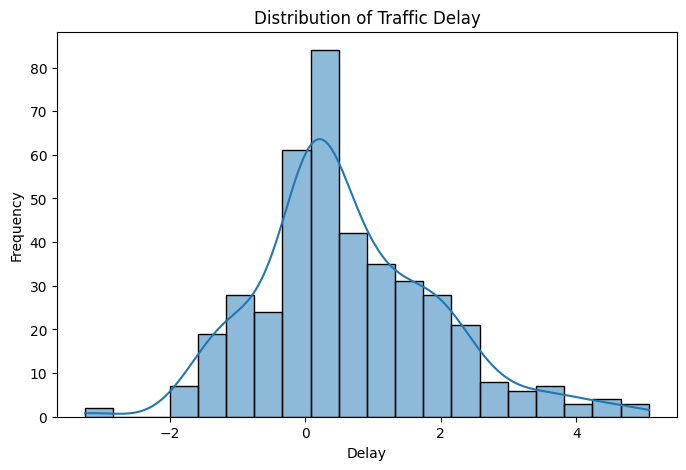

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["delay"], bins=20, kde=True)

plt.xlabel("Delay")
plt.ylabel("Frequency")
plt.title("Distribution of Traffic Delay")

plt.show()

In [17]:
import sys
print(sys.executable)

C:\Users\Nithin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [18]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Nithin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


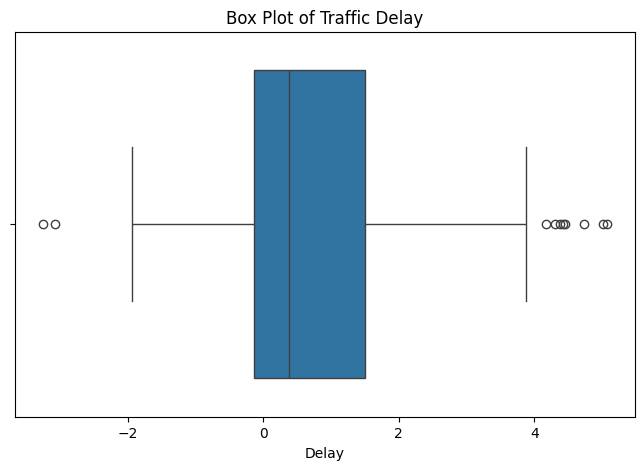

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["delay"])

plt.xlabel("Delay")
plt.title("Box Plot of Traffic Delay")

plt.show()

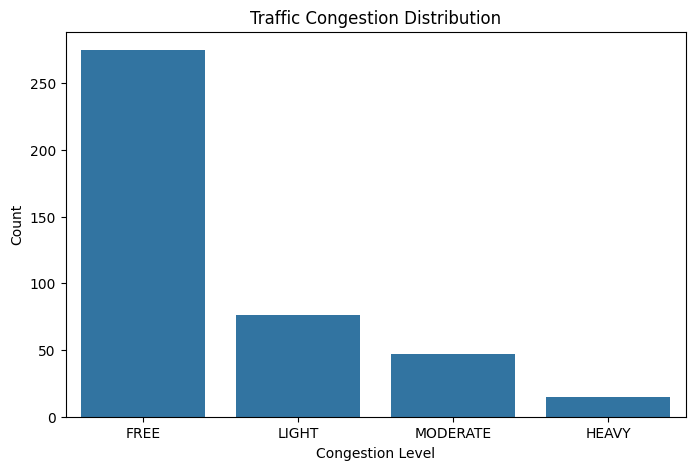

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(x=df["congestion"])

plt.xlabel("Congestion Level")
plt.ylabel("Count")
plt.title("Traffic Congestion Distribution")

plt.show()

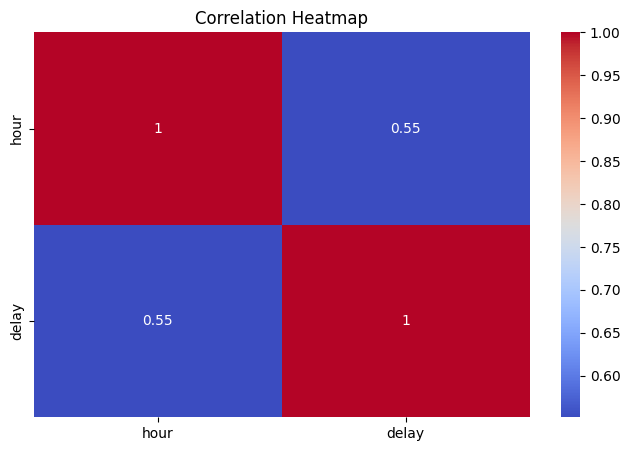

In [18]:
plt.figure(figsize=(8, 5))

correlation = df[["hour", "delay"]].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

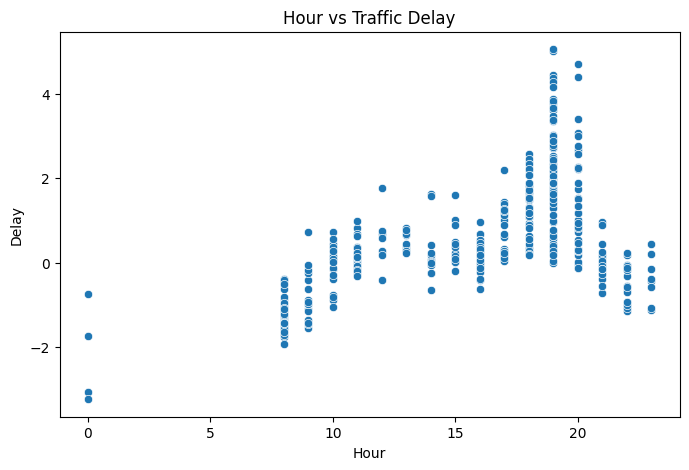

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="hour", y="delay")

plt.xlabel("Hour")
plt.ylabel("Delay")
plt.title("Hour vs Traffic Delay")

plt.show()

In [20]:
print("Final EDA Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Final EDA Dataset Shape: (413, 5)
Missing Values: 0
Duplicate Rows: 0


In [21]:
# ==============================
# PREPROCESSING
# ==============================

# Features used for clustering
features = ["road_id", "hour", "day", "delay"]

X = df[features].copy()

print("Features selected for clustering:")
print(X.columns.tolist())

display(X.head())

Features selected for clustering:
['road_id', 'hour', 'day', 'delay']


,road_id,hour,day,delay
0,R1,14,Monday,0.07
1,R2,14,Monday,-0.65
2,R3,14,Monday,-0.25
3,R4,14,Monday,-0.25
4,R1,16,Monday,-0.23


In [22]:
print("Data types:")
print(X.dtypes)

Data types:
road_id     object
hour         int64
day         object
delay      float64
dtype: object


In [23]:
X_encoded = pd.get_dummies(
    X,
    columns=["road_id", "day"],
    dtype=int
)

print("Shape after encoding:", X_encoded.shape)

display(X_encoded.head())

Shape after encoding: (413, 13)


,hour,delay,road_id_R1,road_id_R2,road_id_R3,road_id_R4,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,14,0.07,1,0,0,0,0,1,0,0,0,0,0
1,14,-0.65,0,1,0,0,0,1,0,0,0,0,0
2,14,-0.25,0,0,1,0,0,1,0,0,0,0,0
3,14,-0.25,0,0,0,1,0,1,0,0,0,0,0
4,16,-0.23,1,0,0,0,0,1,0,0,0,0,0


In [24]:
print("Encoded columns:")
print(X_encoded.columns.tolist())

print("\nData types:")
print(X_encoded.dtypes)

Encoded columns:
['hour', 'delay', 'road_id_R1', 'road_id_R2', 'road_id_R3', 'road_id_R4', 'day_Friday', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']

Data types:
hour               int64
delay            float64
road_id_R1         int64
road_id_R2         int64
road_id_R3         int64
road_id_R4         int64
day_Friday         int64
day_Monday         int64
day_Saturday       int64
day_Sunday         int64
day_Thursday       int64
day_Tuesday        int64
day_Wednesday      int64
dtype: object


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (413, 13)


In [26]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X_encoded.columns
)

display(X_scaled_df.head())

,hour,delay,road_id_R1,road_id_R2,road_id_R3,road_id_R4,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,-0.399017,-0.423861,1.691098,-0.565233,-0.580146,-0.572690,-0.443961,2.425558,-0.3669,-0.26968,-0.404203,-0.408248,-0.53161
1,-0.399017,-0.965337,-0.591332,1.769181,-0.580146,-0.572690,-0.443961,2.425558,-0.3669,-0.26968,-0.404203,-0.408248,-0.53161
2,-0.399017,-0.664517,-0.591332,-0.565233,1.723704,-0.572690,-0.443961,2.425558,-0.3669,-0.26968,-0.404203,-0.408248,-0.53161
3,-0.399017,-0.664517,-0.591332,-0.565233,-0.580146,1.746144,-0.443961,2.425558,-0.3669,-0.26968,-0.404203,-0.408248,-0.53161
4,0.031255,-0.649476,1.691098,-0.565233,-0.580146,-0.572690,-0.443961,2.425558,-0.3669,-0.26968,-0.404203,-0.408248,-0.53161


In [27]:
print("Mean of scaled features:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation of scaled features:")
print(X_scaled_df.std().round(2))

Mean of scaled features:
hour             0.0
delay            0.0
road_id_R1      -0.0
road_id_R2       0.0
road_id_R3      -0.0
road_id_R4      -0.0
day_Friday      -0.0
day_Monday       0.0
day_Saturday     0.0
day_Sunday       0.0
day_Thursday     0.0
day_Tuesday      0.0
day_Wednesday    0.0
dtype: float64

Standard deviation of scaled features:
hour             1.0
delay            1.0
road_id_R1       1.0
road_id_R2       1.0
road_id_R3       1.0
road_id_R4       1.0
day_Friday       1.0
day_Monday       1.0
day_Saturday     1.0
day_Sunday       1.0
day_Thursday     1.0
day_Tuesday      1.0
day_Wednesday    1.0
dtype: float64
